# Elliptic Curve Visualizations

This notebook generates animated GIFs illustrating elliptic curve operations:
1. **Over the reals $\mathbb{R}$**: Drawing curves $y^2 = x^3 + ax + b$, point addition $P+Q$, point doubling $P+P$, with animated "ball" tracing the geometric construction.
2. **Over finite fields $\mathbb{F}_p$**: Discrete point sets with wrapping arithmetic and animated paths.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
import os
from IPython.display import Image as IPImage, display

# ============================================================
# ELLIPTIC CURVE MATH OVER THE REALS
# Curve: y^2 = x^3 + a*x + b
# ============================================================

class RealEllipticCurve:
    """Elliptic curve y^2 = x^3 + ax + b over R."""

    def __init__(self, a, b):
        self.a = a
        self.b = b
        disc = 4 * a**3 + 27 * b**2
        if abs(disc) < 1e-12:
            raise ValueError(f"Curve is singular (discriminant ~ 0)")

    def rhs(self, x):
        """x^3 + ax + b"""
        return x**3 + self.a * x + self.b

    def y_from_x(self, x):
        """Return (y_pos, y_neg) or None if no real point."""
        val = self.rhs(x)
        if val < -1e-15:
            return None
        val = max(val, 0.0)
        y = np.sqrt(val)
        return (y, -y)

    def curve_points(self, x_min, x_max, n=2000):
        """Sample upper and lower branches for plotting."""
        xs = np.linspace(x_min, x_max, n)
        vals = self.rhs(xs)
        mask = vals >= 0
        xs_valid = xs[mask]
        ys = np.sqrt(np.maximum(vals[mask], 0))
        return xs_valid, ys  # upper branch; lower is -ys

    def add(self, P, Q):
        """
        Add two points on the curve.
        Points are (x, y) tuples or 'O' for the point at infinity.

        Group law:
        - P + O = P
        - If P = (x, y) and Q = (x, -y), then P + Q = O
        - If P = Q, use the tangent (doubling formula)
        - Otherwise, secant line through P, Q
        """
        if P == 'O':
            return Q
        if Q == 'O':
            return P

        x1, y1 = P
        x2, y2 = Q

        # P = -Q  (same x, opposite y)
        if abs(x1 - x2) < 1e-12 and abs(y1 + y2) < 1e-12:
            return 'O'

        if abs(x1 - x2) < 1e-12 and abs(y1 - y2) < 1e-12:
            # Point doubling
            if abs(y1) < 1e-12:
                return 'O'  # tangent is vertical
            # m = (3x1^2 + a) / (2y1)
            m = (3 * x1**2 + self.a) / (2 * y1)
        else:
            # Secant
            m = (y2 - y1) / (x2 - x1)

        # x3 = m^2 - x1 - x2
        x3 = m**2 - x1 - x2
        # y3 = m(x1 - x3) - y1
        y3 = m * (x1 - x3) - y1
        return (x3, y3)

    def negate(self, P):
        if P == 'O':
            return 'O'
        return (P[0], -P[1])

    def scalar_mul(self, n, P):
        if n == 0 or P == 'O':
            return 'O'
        if n < 0:
            return self.scalar_mul(-n, self.negate(P))
        result = 'O'
        addend = P
        while n > 0:
            if n % 2 == 1:
                result = self.add(result, addend)
            addend = self.add(addend, addend)
            n //= 2
        return result


# ============================================================
# ELLIPTIC CURVE MATH OVER F_p
# Curve: y^2 = x^3 + ax + b  (mod p)
# ============================================================

class FpEllipticCurve:
    """Elliptic curve y^2 = x^3 + ax + b over F_p."""

    def __init__(self, a, b, p):
        self.a = a % p
        self.b = b % p
        self.p = p
        disc = (4 * pow(a, 3, p) + 27 * pow(b, 2, p)) % p
        if disc == 0:
            raise ValueError(f"Curve is singular over F_{p}")

    def rhs(self, x):
        return (pow(x, 3, self.p) + self.a * x + self.b) % self.p

    def is_on_curve(self, P):
        if P == 'O':
            return True
        x, y = P
        return (y * y - self.rhs(x)) % self.p == 0

    def all_points(self):
        """Enumerate all affine points."""
        pts = []
        p = self.p
        for x in range(p):
            r = self.rhs(x)
            for y in range(p):
                if (y * y) % p == r:
                    pts.append((x, y))
        return pts

    def _mod_inv(self, a, p):
        return pow(a, p - 2, p)

    def add(self, P, Q):
        """Point addition over F_p."""
        p = self.p
        if P == 'O':
            return Q
        if Q == 'O':
            return P

        x1, y1 = P
        x2, y2 = Q

        if x1 % p == x2 % p and (y1 + y2) % p == 0:
            return 'O'

        if x1 % p == x2 % p and y1 % p == y2 % p:
            if y1 % p == 0:
                return 'O'
            m = (3 * x1 * x1 + self.a) * self._mod_inv(2 * y1, p) % p
        else:
            m = (y2 - y1) * self._mod_inv((x2 - x1) % p, p) % p

        x3 = (m * m - x1 - x2) % p
        y3 = (m * (x1 - x3) - y1) % p
        return (x3, y3)

    def negate(self, P):
        if P == 'O':
            return 'O'
        return (P[0], (-P[1]) % self.p)

    def scalar_mul(self, n, P):
        if n == 0 or P == 'O':
            return 'O'
        if n < 0:
            return self.scalar_mul(-n, self.negate(P))
        result = 'O'
        addend = P
        while n > 0:
            if n % 2 == 1:
                result = self.add(result, addend)
            addend = self.add(addend, addend)
            n //= 2
        return result


# ============================================================
# PLOTTING HELPERS - REAL CURVE
# ============================================================

def plot_real_curve(ax, curve, x_range=(-3, 4), n=2000, color='#2070b0', lw=2.0):
    """Draw the elliptic curve on the given axes, correctly handling two-component curves."""
    xl, xr = x_range
    # Find real roots of x³ + ax + b to locate component boundaries.
    all_roots = np.roots([1, 0, curve.a, curve.b])
    real_roots = sorted(r.real for r in all_roots if abs(r.imag) < 1e-6)

    # Build x-intervals where rhs(x) >= 0:
    #   3 real roots r0 < r1 < r2 → oval on [r0, r1], unbounded on [r2, +∞)
    #   1 real root  r0            → single component on [r0, +∞)
    if len(real_roots) == 3:
        r0, r1, r2 = real_roots
        segments = [(r0, r1), (r2, xr)]
    else:
        segments = [(real_roots[0], xr)]

    for lo, hi in segments:
        lo, hi = max(lo, xl), min(hi, xr)
        if lo >= hi:
            continue
        xs = np.linspace(lo, hi, n)
        ys = np.sqrt(np.maximum(curve.rhs(xs), 0))
        ax.plot(xs, ys, color=color, lw=lw)
        ax.plot(xs, -ys, color=color, lw=lw)

    ax.axhline(0, color='gray', lw=0.4)
    ax.axvline(0, color='gray', lw=0.4)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

def mark_points(ax, points, labels=None, color='red', size=60, fontsize=14):
    """Mark points on the curve."""
    for i, P in enumerate(points):
        if P == 'O':
            continue
        ax.scatter(*P, color=color, s=size, zorder=5)
        if labels and i < len(labels):
            ax.annotate(labels[i], P, textcoords="offset points",
                        xytext=(8, 8), fontsize=fontsize, color=color,
                        fontweight='bold')

def draw_line_through(ax, P, Q, curve, x_range=(-3, 4), color='#d04040', lw=1.5, ls='--'):
    """Draw the line through P and Q (or tangent at P if P==Q)."""
    if P == 'O' or Q == 'O':
        return None
    x1, y1 = P
    x2, y2 = Q
    if abs(x1 - x2) < 1e-12 and abs(y1 - y2) < 1e-12:
        if abs(y1) < 1e-12:
            ax.axvline(x1, color=color, lw=lw, ls=ls)
            return None
        m = (3 * x1**2 + curve.a) / (2 * y1)
    else:
        if abs(x1 - x2) < 1e-12:
            ax.axvline(x1, color=color, lw=lw, ls=ls)
            return None
        m = (y2 - y1) / (x2 - x1)
    c = y1 - m * x1
    xl, xr = x_range
    ax.plot([xl, xr], [m * xl + c, m * xr + c], color=color, lw=lw, ls=ls)
    return m, c


# ============================================================
# ANIMATION - REAL CURVE
# ============================================================

def animate_real_addition(curve, P, Q, filename='ec_add.gif',
                          x_range=(-3, 4), y_range=(-5, 5),
                          figsize=(7, 7), n_frames=60, fps=30,
                          title=None, ball_color='#e04040', ball_size=120):
    """
    Animated GIF of point addition P + Q on a real elliptic curve.
    Ball: P -> R' (along line) -> R = P+Q (vertical reflection).
    """
    R = curve.add(P, Q)
    R_prime = curve.negate(R)  # third intersection before reflection

    x1, y1 = P
    if abs(P[0] - Q[0]) < 1e-12 and abs(P[1] - Q[1]) < 1e-12:
        if abs(y1) < 1e-12:
            raise ValueError("Tangent is vertical at this point")
        m = (3 * x1**2 + curve.a) / (2 * y1)
    else:
        if abs(P[0] - Q[0]) < 1e-12:
            raise ValueError("Vertical line - result is point at infinity")
        m = (Q[1] - P[1]) / (Q[0] - P[0])
    c_line = y1 - m * x1

    n1 = n_frames * 2 // 3   # frames: P -> R'
    n2 = n_frames - n1        # frames: R' -> R

    frames = []
    for frame_idx in range(n_frames + 10):
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        plot_real_curve(ax, curve, x_range=x_range)
        ax.set_xlim(x_range)
        ax.set_ylim(y_range)

        # Construction lines
        xl, xr = x_range
        ax.plot([xl, xr], [m*xl+c_line, m*xr+c_line],
                color='#d04040', lw=1.5, ls='--', alpha=0.6)
        if R != 'O' and R_prime != 'O':
            ax.plot([R_prime[0], R[0]], [R_prime[1], R[1]],
                    color='#40a040', lw=1.2, ls=':', alpha=0.6)

        # Static points
        mark_points(ax, [P], labels=['P'], color='#2060a0')
        if not (abs(P[0]-Q[0])<1e-12 and abs(P[1]-Q[1])<1e-12):
            mark_points(ax, [Q], labels=['Q'], color='#2060a0')
        if R_prime != 'O':
            mark_points(ax, [R_prime], labels=["P*Q"], color='#808080', size=40)
        if R != 'O':
            mark_points(ax, [R], labels=['P+Q'], color='#208020')

        # Ball
        if frame_idx < n1:
            t = frame_idx / max(n1 - 1, 1)
            bx = P[0] + t * (R_prime[0] - P[0])
            by = P[1] + t * (R_prime[1] - P[1])
        elif frame_idx < n1 + n2:
            t = (frame_idx - n1) / max(n2 - 1, 1)
            bx = R_prime[0] + t * (R[0] - R_prime[0])
            by = R_prime[1] + t * (R[1] - R_prime[1])
        else:
            bx, by = R

        ax.scatter(bx, by, color=ball_color, s=ball_size, zorder=10,
                   edgecolors='black', linewidths=0.8)
        if title:
            ax.set_title(title, fontsize=14)
        fig.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100)
        plt.close(fig)
        buf.seek(0)
        frames.append(Image.open(buf).copy())

    duration = int(1000 / fps)
    os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
    frames[0].save(filename, save_all=True, append_images=frames[1:],
                   duration=duration, loop=0)
    return filename


# ============================================================
# PLOTTING AND ANIMATION - F_p CURVE
# ============================================================

def plot_fp_curve(ax, curve, point_color='#2070b0', size=80):
    """Plot all points of the curve over F_p."""
    pts = curve.all_points()
    if pts:
        xs, ys = zip(*pts)
        ax.scatter(xs, ys, color=point_color, s=size, zorder=3,
                   edgecolors='black', linewidths=0.5)
    p = curve.p
    ax.set_xlim(-0.5, p - 0.5)
    ax.set_ylim(-0.5, p - 0.5)
    ax.set_xticks(range(p))
    ax.set_yticks(range(p))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

def draw_fp_line(ax, curve, P, Q, color='#d04040', ms=15):
    """Mark all points on the line through P,Q in F_p."""
    p = curve.p
    x1, y1 = P
    x2, y2 = Q

    if x1 % p == x2 % p and y1 % p == y2 % p:
        if y1 % p == 0:
            return
        m = (3 * x1 * x1 + curve.a) * pow(2 * y1, p - 2, p) % p
    else:
        if (x2 - x1) % p == 0:
            return
        m = (y2 - y1) * pow((x2 - x1) % p, p - 2, p) % p
    c_val = (y1 - m * x1) % p

    xs = list(range(p))
    ys = [(m * x + c_val) % p for x in xs]
    ax.scatter(xs, ys, color=color, s=ms, marker='x', zorder=4, alpha=0.6)


def animate_fp_addition(curve, P, Q, filename='ec_fp_add.gif',
                        figsize=(7, 7), n_frames=80, fps=20,
                        title=None, ball_color='#e04040', ball_size=160):
    """
    Animate point addition on F_p.
    Ball travels along the line (wrapping mod p) from P to R',
    then moves vertically to R = P+Q (reflection).
    """
    p = curve.p
    R = curve.add(P, Q)
    R_prime = curve.negate(R)

    if R == 'O' or R_prime == 'O':
        raise ValueError("Result is O - cannot animate to infinity")

    # Compute slope
    x1, y1 = P
    x2, y2 = Q
    if x1 % p == x2 % p and y1 % p == y2 % p:
        if y1 % p == 0:
            raise ValueError("Tangent is vertical")
        m = (3 * x1 * x1 + curve.a) * pow(2 * y1, p - 2, p) % p
    else:
        if (x2 - x1) % p == 0:
            raise ValueError("Vertical line")
        m = (y2 - y1) * pow((x2 - x1) % p, p - 2, p) % p
    c_val = (y1 - m * x1) % p

    # Path: step x from P's x to R_prime's x, one unit at a time mod p
    visited = []
    x = x1
    visited.append((x, (m * x + c_val) % p))
    for _ in range(p):
        x = (x + 1) % p
        visited.append((x, (m * x + c_val) % p))
        if x == R_prime[0] % p:
            break

    n1 = n_frames * 2 // 3
    n2 = n_frames - n1

    frames = []
    for frame_idx in range(n_frames + 15):
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        plot_fp_curve(ax, curve)
        draw_fp_line(ax, curve, P, Q)

        mark_points(ax, [P], labels=['P'], color='#2060a0')
        if not (P[0] == Q[0] and P[1] == Q[1]):
            mark_points(ax, [Q], labels=['Q'], color='#2060a0')
        mark_points(ax, [R_prime], labels=["P*Q"], color='#808080', size=40)
        mark_points(ax, [R], labels=['P+Q'], color='#208020')

        ax.plot([R_prime[0], R[0]], [R_prime[1], R[1]],
                color='#40a040', lw=1.5, ls=':', alpha=0.7)

        if frame_idx < n1:
            t = frame_idx / max(n1 - 1, 1)
            idx = t * (len(visited) - 1)
            i0 = int(idx)
            i1 = min(i0 + 1, len(visited) - 1)
            frac = idx - i0
            bx0, by0 = visited[i0]
            bx1, by1 = visited[i1]
            # wrap-aware lerp
            dx = (bx1 - bx0 + p/2) % p - p/2
            dy = (by1 - by0 + p/2) % p - p/2
            bx = (bx0 + frac * dx) % p
            by = (by0 + frac * dy) % p
        elif frame_idx < n1 + n2:
            t = (frame_idx - n1) / max(n2 - 1, 1)
            bx = float(R_prime[0])
            dy = (R[1] - R_prime[1] + p//2) % p - p//2
            by = (R_prime[1] + t * dy) % p
        else:
            bx, by = float(R[0]), float(R[1])

        ax.scatter(bx, by, color=ball_color, s=ball_size, zorder=10,
                   edgecolors='black', linewidths=1.0)
        if title:
            ax.set_title(title, fontsize=14)
        fig.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100)
        plt.close(fig)
        buf.seek(0)
        frames.append(Image.open(buf).copy())

    duration = int(1000 / fps)
    os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
    frames[0].save(filename, save_all=True, append_images=frames[1:],
                   duration=duration, loop=0)
    return filename


def show_gif(path):
    """Display a GIF inline in the notebook."""
    display(IPImage(filename=path))

print("Library loaded.")

Library loaded.


## Real Curve: Drawing $y^2 = x^3 - x + 1$

A basic plot of the curve with marked points.

Saved: real_curve_basic.png


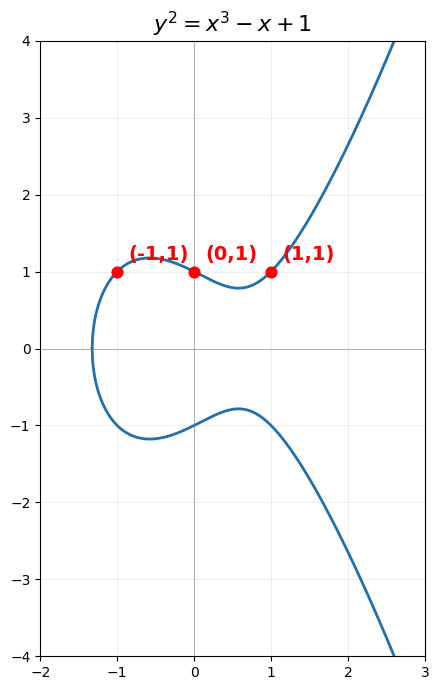

In [17]:
# Draw y^2 = x^3 - x + 1 with a few points marked
E = RealEllipticCurve(a=-1, b=1)

fig, ax = plt.subplots(figsize=(7, 7))
plot_real_curve(ax, E, x_range=(-2, 3))
ax.set_xlim(-2, 3)
ax.set_ylim(-4, 4)

# Pick some points on the curve
P = (-1, 1)   # (-1)^3 + (-1)(-1) + 1 = -1+1+1 = 1, y=1 ✓
Q = (0, 1)    # 0 + 0 + 1 = 1, y=1 ✓
R_pt = (1, 1) # 1 - 1 + 1 = 1, y=1 ✓

mark_points(ax, [P, Q, R_pt], labels=['(-1,1)', '(0,1)', '(1,1)'], color='red')

ax.set_title(r"$y^2 = x^3 - x + 1$", fontsize=16)
fig.tight_layout()
fig.savefig('real_curve_basic.png', dpi=150)
print("Saved: real_curve_basic.png")

## Real Curve: Line Through Two Points & Third Intersection

Given $P=(-1,1)$ and $Q=(0,1)$ on $y^2=x^3-x+1$, we draw the secant line and find the third intersection point $P*Q$, then reflect to get $P+Q$.

P = (-1, 1)
Q = (0, 1)
Third intersection P*Q = (1.0000, 1.0000)
P + Q = (1.0000, -1.0000)
Verification: y² - (x³+ax+b) at P+Q = 0.00e+00


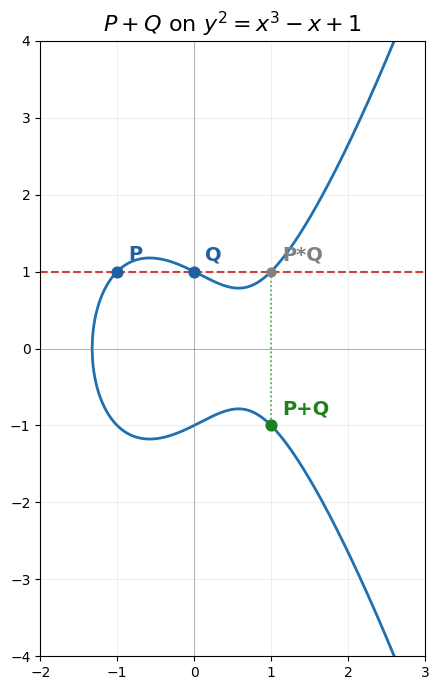

In [3]:
# Point addition: P + Q on y^2 = x^3 - x + 1
E = RealEllipticCurve(a=-1, b=1)

P = (-1, 1)
Q = (0, 1)
R = E.add(P, Q)          # P+Q (final result, after reflection)
R_prime = E.negate(R)     # third intersection before reflection

print(f"P = {P}")
print(f"Q = {Q}")
print(f"Third intersection P*Q = ({R_prime[0]:.4f}, {R_prime[1]:.4f})")
print(f"P + Q = ({R[0]:.4f}, {R[1]:.4f})")

# Verify R is on the curve
val = R[1]**2 - E.rhs(R[0])
print(f"Verification: y² - (x³+ax+b) at P+Q = {val:.2e}")

fig, ax = plt.subplots(figsize=(7, 7))
plot_real_curve(ax, E, x_range=(-2, 3))
ax.set_xlim(-2, 3)
ax.set_ylim(-4, 4)

draw_line_through(ax, P, Q, E, x_range=(-2, 3))

# Vertical reflection line
ax.plot([R_prime[0], R[0]], [R_prime[1], R[1]],
        color='#40a040', lw=1.2, ls=':')

mark_points(ax, [P, Q], labels=['P', 'Q'], color='#2060a0')
mark_points(ax, [R_prime], labels=['P*Q'], color='#808080', size=40)
mark_points(ax, [R], labels=['P+Q'], color='#208020')

ax.set_title(r"$P + Q$ on $y^2 = x^3 - x + 1$", fontsize=16)
fig.tight_layout()
fig.savefig('real_curve_addition.png', dpi=150)

## Animated: Point Addition $P + Q$ over $\mathbb{R}$

A ball travels from $P$ along the secant line to the third intersection $P*Q$, then reflects vertically to $P+Q$.

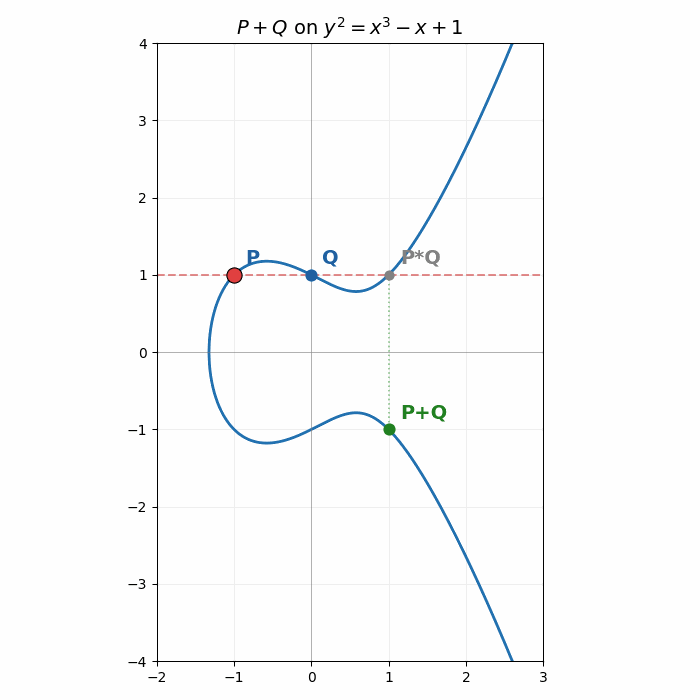

In [4]:
# Animated GIF: P + Q on y^2 = x^3 - x + 1
E = RealEllipticCurve(a=-1, b=1)
P = (-1, 1)
Q = (0, 1)

gif_path = animate_real_addition(
    E, P, Q,
    filename='ec_real_add_PQ.gif',
    x_range=(-2, 3), y_range=(-4, 4),
    n_frames=60, fps=25,
    title=r"$P+Q$ on $y^2 = x^3 - x + 1$"
)
show_gif(gif_path)

## Animated: Point Doubling $P + P$ over $\mathbb{R}$

When $P = Q$, the line is the tangent to the curve at $P$. The ball follows the tangent to the third intersection, then reflects.

P = (0, 1)
2P = (0.2500, -0.8750)


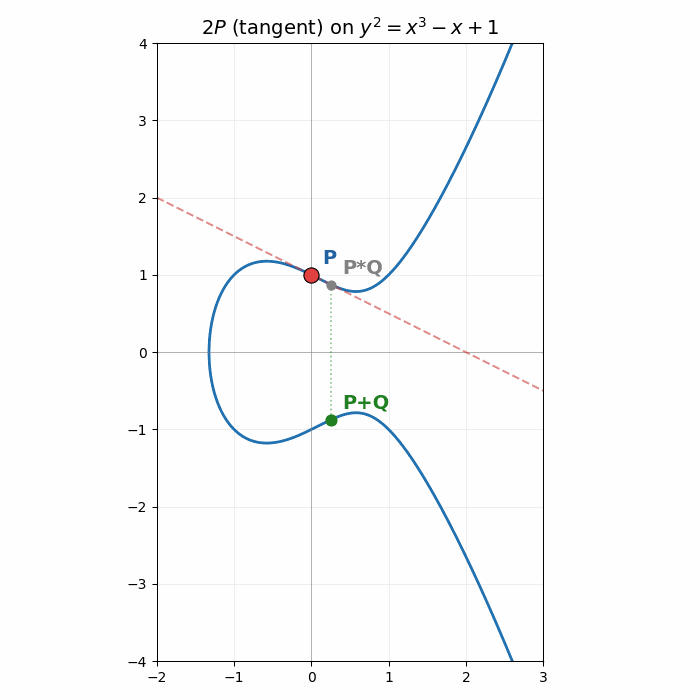

In [5]:
# Animated GIF: Point doubling P + P (tangent line)
E = RealEllipticCurve(a=-1, b=1)
P = (0, 1)

R = E.add(P, P)
print(f"P = {P}")
print(f"2P = ({R[0]:.4f}, {R[1]:.4f})")

gif_path = animate_real_addition(
    E, P, P,
    filename='ec_real_double_P.gif',
    x_range=(-2, 3), y_range=(-4, 4),
    n_frames=60, fps=25,
    title=r"$2P$ (tangent) on $y^2 = x^3 - x + 1$"
)
show_gif(gif_path)

## Another Real Curve: $y^2 = x^3 - 3x + 3$ (two-component curve)

This curve has the classic two-component shape. We animate addition with points on different components.

P = (1, 1), on curve: y²=1.0000, rhs=1.0000
Q = (0, 1.7321), on curve: y²=3.0000, rhs=3.0000
P + Q = (-0.4641, -2.0718)


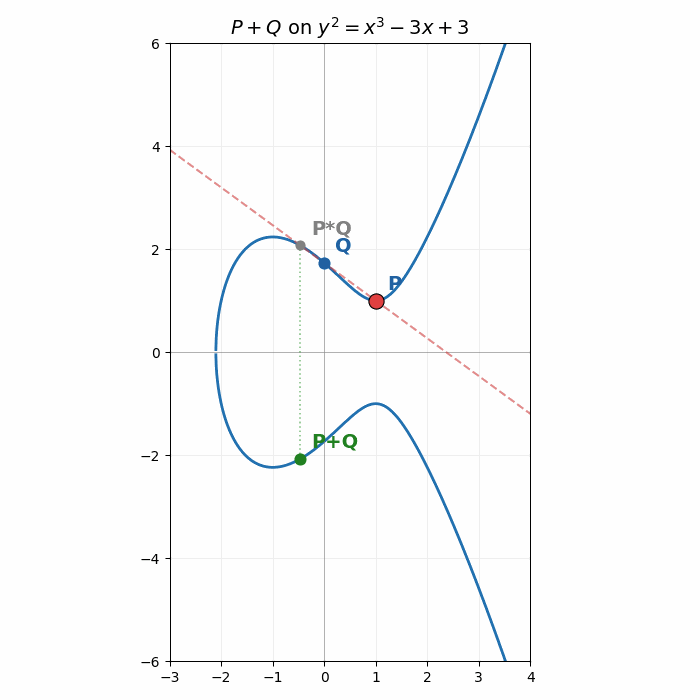

In [6]:
# y^2 = x^3 - 3x + 3: addition with well-separated points
E2 = RealEllipticCurve(a=-3, b=3)

# Find nice points: x=0 -> y^2=3, y=sqrt(3)
# x=1 -> y^2=1, y=1
P = (1, 1)
Q = (0, np.sqrt(3))

print(f"P = {P}, on curve: y²={P[1]**2:.4f}, rhs={E2.rhs(P[0]):.4f}")
print(f"Q = ({Q[0]}, {Q[1]:.4f}), on curve: y²={Q[1]**2:.4f}, rhs={E2.rhs(Q[0]):.4f}")

R = E2.add(P, Q)
print(f"P + Q = ({R[0]:.4f}, {R[1]:.4f})")

gif_path = animate_real_addition(
    E2, P, Q,
    filename='ec_real_add_PQ_v2.gif',
    x_range=(-3, 4), y_range=(-6, 6),
    n_frames=60, fps=25,
    title=r"$P+Q$ on $y^2 = x^3 - 3x + 3$"
)
show_gif(gif_path)

---

## Finite Field: Curve over $\mathbb{F}_p$

Now we work with $y^2 \equiv x^3 + ax + b \pmod{p}$. Points are pairs of integers in $\{0, \ldots, p-1\}$.

### Plotting $y^2 = x^3 + x + 1$ over $\mathbb{F}_{23}$

Number of affine points: 27 (plus the point at infinity)


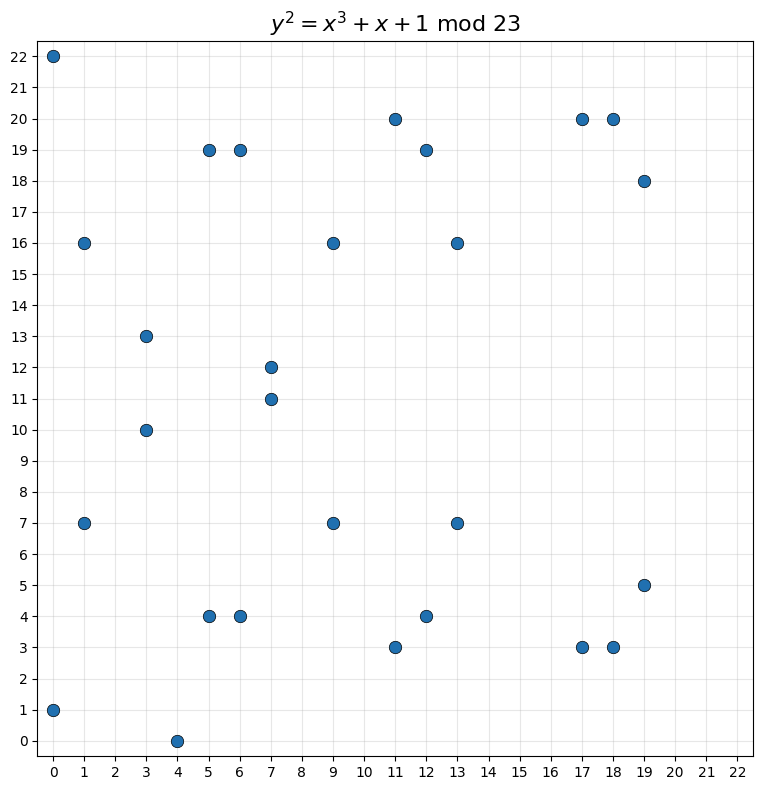

In [7]:
# Plot y^2 = x^3 + x + 1 over F_23
Ep = FpEllipticCurve(a=1, b=1, p=23)
pts = Ep.all_points()
print(f"Number of affine points: {len(pts)} (plus the point at infinity)")

fig, ax = plt.subplots(figsize=(8, 8))
plot_fp_curve(ax, Ep)
ax.set_title("$y^2 = x^3 + x + 1$ mod 23", fontsize=16)
fig.tight_layout()
fig.savefig('fp_curve_23.png', dpi=150)

### Point Addition over $\mathbb{F}_{23}$: Static Illustration

We pick two points $P$ and $Q$, draw the "line" through them (all $(x, mx+c \bmod p)$ points), find the third intersection $P*Q$, and reflect to get $P+Q$.

P = (0, 1), on curve: True
Q = (1, 16), on curve: True
P*Q (third intersection) = (17, 3)
P+Q = (17, 20), on curve: True


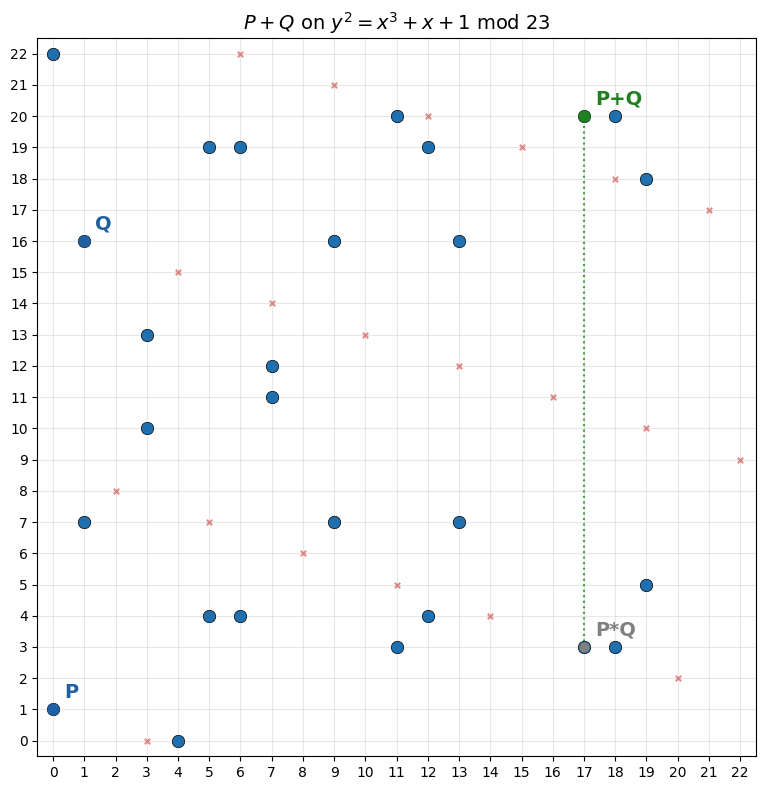

In [8]:
# Static illustration of P + Q over F_23
Ep = FpEllipticCurve(a=1, b=1, p=23)
pts = Ep.all_points()

# Pick two points from the curve
P = pts[0]
Q = pts[3]
R = Ep.add(P, Q)
R_prime = Ep.negate(R)

print(f"P = {P}, on curve: {Ep.is_on_curve(P)}")
print(f"Q = {Q}, on curve: {Ep.is_on_curve(Q)}")
print(f"P*Q (third intersection) = {R_prime}")
print(f"P+Q = {R}, on curve: {Ep.is_on_curve(R)}")

fig, ax = plt.subplots(figsize=(8, 8))
plot_fp_curve(ax, Ep)
draw_fp_line(ax, Ep, P, Q)

# Reflection line
ax.plot([R_prime[0], R[0]], [R_prime[1], R[1]],
        color='#40a040', lw=1.5, ls=':')

mark_points(ax, [P, Q], labels=['P', 'Q'], color='#2060a0')
mark_points(ax, [R_prime], labels=['P*Q'], color='#808080', size=40)
mark_points(ax, [R], labels=['P+Q'], color='#208020')

ax.set_title("$P+Q$ on $y^2 = x^3+x+1$ mod 23", fontsize=14)
fig.tight_layout()
fig.savefig('fp_addition_static.png', dpi=150)

### Animated: Point Addition over $\mathbb{F}_{23}$

The ball wraps around the $p \times p$ grid as it follows the line.

P = (0, 1), Q = (1, 16), P+Q = (17, 20)


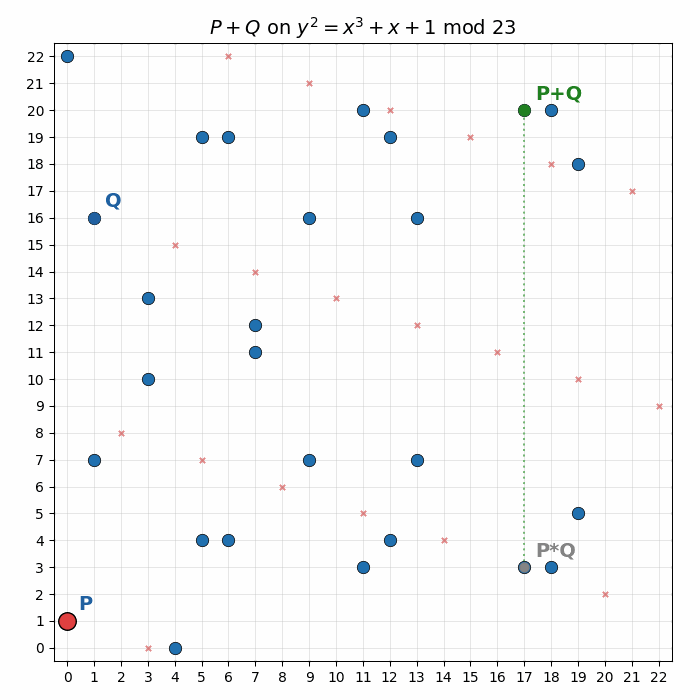

In [9]:
# Animated GIF: P + Q over F_23
Ep = FpEllipticCurve(a=1, b=1, p=23)
pts = Ep.all_points()

P = pts[0]
Q = pts[3]
R = Ep.add(P, Q)
print(f"P = {P}, Q = {Q}, P+Q = {R}")

gif_path = animate_fp_addition(
    Ep, P, Q,
    filename='ec_fp_add_PQ.gif',
    n_frames=80, fps=20,
    title="$P+Q$ on $y^2 = x^3+x+1$ mod 23"
)
show_gif(gif_path)

### Animated: Point Doubling over $\mathbb{F}_{23}$

P = (1, 7), 2P = (7, 11)


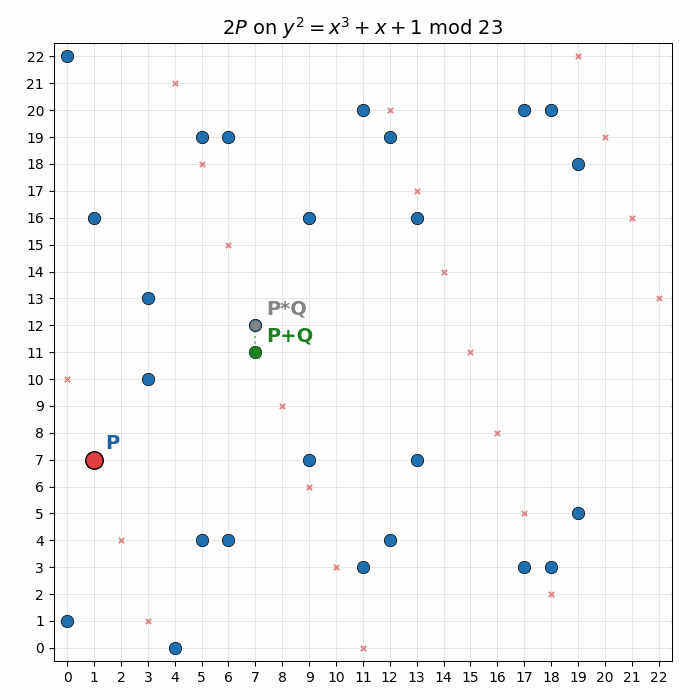

In [10]:
# Animated GIF: Point doubling P + P over F_23
Ep = FpEllipticCurve(a=1, b=1, p=23)
pts = Ep.all_points()

P = pts[2]  # pick a point with y != 0
R = Ep.add(P, P)
print(f"P = {P}, 2P = {R}")

gif_path = animate_fp_addition(
    Ep, P, P,
    filename='ec_fp_double_P.gif',
    n_frames=80, fps=20,
    title="$2P$ on $y^2 = x^3+x+1$ mod 23"
)
show_gif(gif_path)

### Scalar Multiplication: Computing $nP$ over $\mathbb{F}_{23}$

We compute successive multiples of a generator point and display them all on the curve, showing how they "jump around" the field.

Order of G=(0, 1) is 28


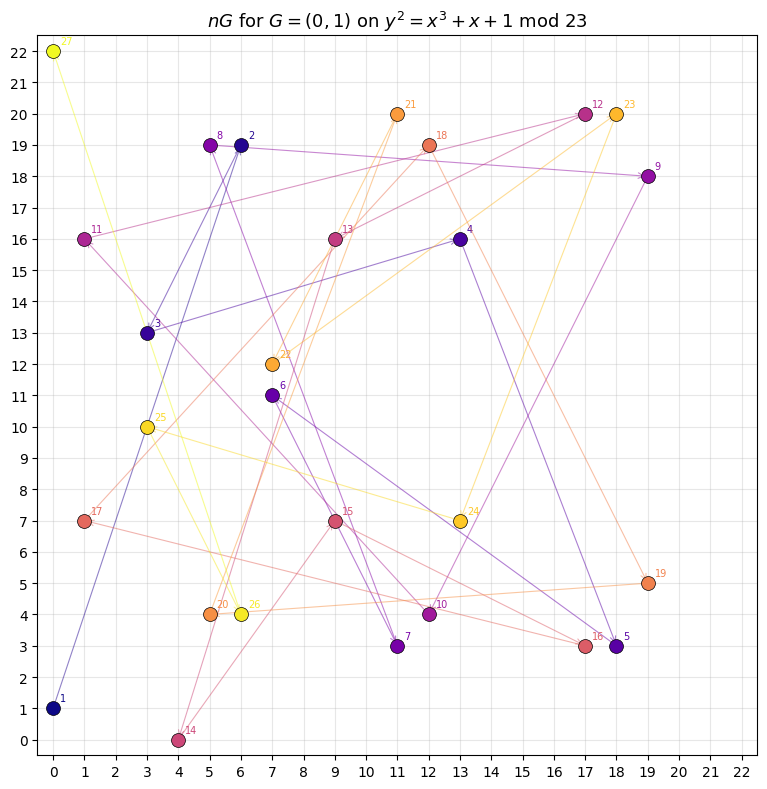

In [11]:
# Scalar multiplication: show nP for n = 1, 2, ..., order
Ep = FpEllipticCurve(a=1, b=1, p=23)
pts = Ep.all_points()
G = pts[0]  # generator candidate

# Compute multiples until we hit O
multiples = []
for n in range(1, len(pts) + 2):
    nP = Ep.scalar_mul(n, G)
    if nP == 'O':
        print(f"Order of G={G} is {n}")
        break
    multiples.append(nP)

fig, ax = plt.subplots(figsize=(8, 8))
plot_fp_curve(ax, Ep, point_color='#d0d0d0', size=50)

# Draw arrows connecting successive multiples
import matplotlib.colors as mcolors
cmap = plt.cm.plasma
for i, pt in enumerate(multiples):
    color = cmap(i / max(len(multiples)-1, 1))
    ax.scatter(*pt, color=color, s=100, zorder=5, edgecolors='black', linewidths=0.5)
    ax.annotate(str(i+1), pt, textcoords="offset points",
                xytext=(5, 5), fontsize=7, color=color)
    if i > 0:
        prev = multiples[i-1]
        ax.annotate("", xy=pt, xytext=prev,
                     arrowprops=dict(arrowstyle='->', color=color, lw=0.8, alpha=0.5))

ax.set_title(f"$nG$ for $G={G}$ on $y^2 = x^3+x+1$ mod 23", fontsize=13)
fig.tight_layout()
fig.savefig('fp_scalar_mul.png', dpi=150)

# Gadi's part

In [12]:
E = RealEllipticCurve(a=-1, b=1)
x_range=(-3, 3)
E.curve_points(x_range[0], x_range[1], 10)


(array([-1.        , -0.33333333,  0.33333333,  1.        ,  1.66666667,
         2.33333333,  3.        ]),
 array([1.        , 1.13855009, 0.83887049, 1.        , 1.99071921,
        3.37199798, 5.        ]))

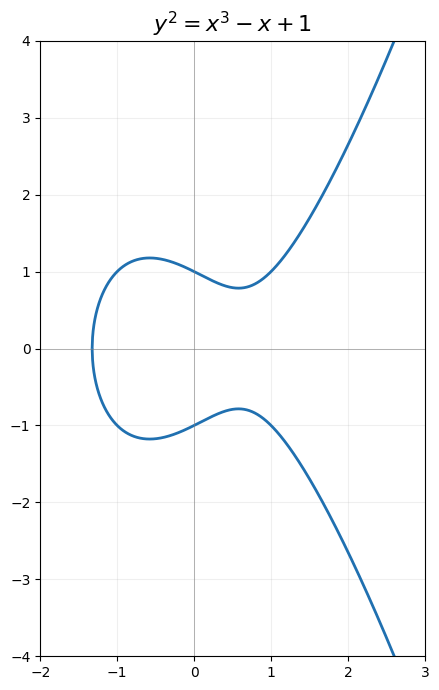

In [13]:
# Draw y^2 = x^3 - x + 1 with a few points marked
E = RealEllipticCurve(a=-1, b=1)
x_range=(-2, 3)

fig, ax = plt.subplots(figsize=(7, 7))
plot_real_curve(ax, E, x_range=x_range)
ax.set_xlim(x_range)
ax.set_ylim(-4, 4)

# Pick some points on the curve
P = (-1, 1)   # (-1)^3 + (-1)(-1) + 1 = -1+1+1 = 1, y=1 ✓
Q = (0, 1)    # 0 + 0 + 1 = 1, y=1 ✓
R_pt = (1, 1) # 1 - 1 + 1 = 1, y=1 ✓

# mark_points(ax, [P, Q, R_pt], labels=['(-1,1)', '(0,1)', '(1,1)'], color='red')

ax.set_title(r"$y^2 = x^3 - x + 1$", fontsize=16)
fig.tight_layout()
# fig.savefig('real_curve_basic.png', dpi=150)
# print("Saved: real_curve_basic.png")

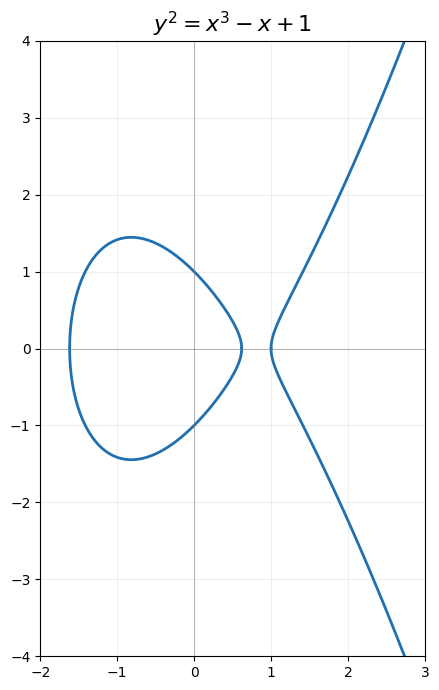

In [16]:
# Draw y^2 = x^3 - x + 1 with a few points marked
E = RealEllipticCurve(a=-2, b=1)
x_range=(-2, 3)

fig, ax = plt.subplots(figsize=(7, 7))
plot_real_curve(ax, E, x_range=x_range)
ax.set_xlim(x_range)
ax.set_ylim(-4, 4)

# Pick some points on the curve
P = (-1, 1)   # (-1)^3 + (-1)(-1) + 1 = -1+1+1 = 1, y=1 ✓
Q = (0, 1)    # 0 + 0 + 1 = 1, y=1 ✓
R_pt = (1, 1) # 1 - 1 + 1 = 1, y=1 ✓

# mark_points(ax, [P, Q, R_pt], labels=['(-1,1)', '(0,1)', '(1,1)'], color='red')

ax.set_title(r"$y^2 = x^3 - x + 1$", fontsize=16)
fig.tight_layout()
# fig.savefig('real_curve_basic.png', dpi=150)
# print("Saved: real_curve_basic.png")